# Bayesian Monte Carlo Verification
## *Does the theory hold when you simulate 80 million people?*

In `bayesian_inference_medical_testing.ipynb` we derived the posterior probability of infection analytically using Bayes' Theorem. The math told us that for a disease with 1‰ prevalence, even a 97% accurate test leaves a positive result with only ~1.9% chance of being real.

This notebook asks: **what actually happens when you simulate the entire population?**

We generate 80 million virtual people, infect them at the real base rate, run the test on each one, and count the outcomes. No formulas — just simulation. Then we compare the empirical results against the analytical Bayesian predictions.

If the theory is correct, they should agree.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)

---
## Parameters

Same test characteristics as the analytical notebook:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| Population | 80,000,000 | Germany-scale population |
| Prior (base rate) | 1‰ = 0.001 | Disease prevalence in general population |
| Sensitivity | 0.97 | P(positive \| infected) — true positive rate |
| False positive rate | 0.05 | P(positive \| healthy) |
| Specificity | 0.95 | P(negative \| healthy) — true negative rate |

In [2]:
N                   = 80_000_000   # population size
prior               = 0.001        # 1 per mille base rate
p_pos_given_infected = 0.97        # sensitivity
p_pos_given_healthy  = 0.05        # false positive rate

---
## Step 1 — Infect the Population

Each person is independently infected with probability equal to the base rate.
We draw a uniform random number for each person — if it falls below the prior, they are infected.

In [3]:
# Draw uniform random numbers for each person
# If r < prior → infected, otherwise healthy
r_infection = np.random.uniform(0, 1, N)
infected    = r_infection < prior

n_infected = infected.sum()
n_healthy  = N - n_infected

print(f"Population        : {N:,}")
print(f"Truly infected    : {n_infected:,}  ({n_infected/N:.4%})")
print(f"Truly healthy     : {n_healthy:,}  ({n_healthy/N:.4%})")
print(f"\nExpected infected : {N * prior:,.0f}  (theoretical at exact 1‰)")
print(f"Difference        : {abs(n_infected - N * prior):,.0f} people  (sampling noise)")

Population        : 80,000,000
Truly infected    : 80,185  (0.1002%)
Truly healthy     : 79,919,815  (99.8998%)

Expected infected : 80,000  (theoretical at exact 1‰)
Difference        : 185 people  (sampling noise)


---
## Step 2 — Run the Test

Each person is tested. The test result depends on their true infection state:
- If **infected**: positive with probability 0.97 (sensitivity)
- If **healthy**: positive with probability 0.05 (false positive rate)

Again we draw fresh uniform random numbers and compare against the appropriate threshold.

In [4]:
# Draw a fresh uniform random number for each person's test
r_test = np.random.uniform(0, 1, N)

# Test result depends on true infection state
# Infected person: positive if r < 0.97
# Healthy person:  positive if r < 0.05
test_positive = np.where(infected, r_test < p_pos_given_infected,
                                   r_test < p_pos_given_healthy)

n_positive = test_positive.sum()
n_negative = N - n_positive

print(f"Test positive     : {n_positive:,}  ({n_positive/N:.4%})")
print(f"Test negative     : {n_negative:,}  ({n_negative/N:.4%})")

Test positive     : 4,073,201  (5.0915%)
Test negative     : 75,926,799  (94.9085%)


---
## Step 3 — Count the Four Outcomes

Every person falls into one of four categories:

| | Test Positive | Test Negative |
|---|---|---|
| **Infected** | True Positive (TP) | False Negative (FN) |
| **Healthy** | False Positive (FP) | True Negative (TN) |

In [5]:
# The four outcome categories
TP = ( infected &  test_positive).sum()  # infected AND tested positive
FN = ( infected & ~test_positive).sum()  # infected AND tested negative
FP = (~infected &  test_positive).sum()  # healthy  AND tested positive
TN = (~infected & ~test_positive).sum()  # healthy  AND tested negative

print("Confusion matrix results:")
print(f"\n  True Positives  (infected, test +) : {TP:>10,}")
print(f"  False Negatives (infected, test -) : {FN:>10,}")
print(f"  False Positives (healthy,  test +) : {FP:>10,}")
print(f"  True Negatives  (healthy,  test -) : {TN:>10,}")
print(f"\n  Total                              : {TP+FN+FP+TN:>10,}")

print(f"\nKey ratios:")
print(f"  Sensitivity (TP / all infected)    : {TP/(TP+FN):.4f}  (expected: {p_pos_given_infected})")
print(f"  False positive rate (FP / healthy) : {FP/(FP+TN):.4f}  (expected: {p_pos_given_healthy})")

Confusion matrix results:

  True Positives  (infected, test +) :     77,720
  False Negatives (infected, test -) :      2,465
  False Positives (healthy,  test +) :  3,995,481
  True Negatives  (healthy,  test -) : 75,924,334

  Total                              : 80,000,000

Key ratios:
  Sensitivity (TP / all infected)    : 0.9693  (expected: 0.97)
  False positive rate (FP / healthy) : 0.0500  (expected: 0.05)


---
## Step 4 — The Core Question

Given a **positive test result**, what fraction of those people are actually infected?

This is the posterior probability P(infected | positive) — the quantity Bayes' Theorem predicts analytically.

In [6]:
# Empirical posterior: among all positive tests, what fraction are truly infected?
posterior_empirical = TP / (TP + FP)

# Analytical Bayes prediction
p_positive = p_pos_given_infected * prior + p_pos_given_healthy * (1 - prior)
posterior_analytical = (p_pos_given_infected * prior) / p_positive

print(f"Among all {TP + FP:,} positive tests:")
print(f"  True positives  : {TP:,}  ({TP/(TP+FP):.1%} of positives)")
print(f"  False positives : {FP:,}  ({FP/(TP+FP):.1%} of positives)")
print(f"\nP(infected | positive test):")
print(f"  Empirical (simulation) : {posterior_empirical:.6f}  ({posterior_empirical:.4%})")
print(f"  Analytical (Bayes)     : {posterior_analytical:.6f}  ({posterior_analytical:.4%})")
print(f"  Difference             : {abs(posterior_empirical - posterior_analytical):.6f}")
print(f"\nConclusion: of every 100 people who test positive, only ~{posterior_empirical*100:.1f} are actually infected.")

Among all 4,073,201 positive tests:
  True positives  : 77,720  (1.9% of positives)
  False positives : 3,995,481  (98.1% of positives)

P(infected | positive test):
  Empirical (simulation) : 0.019081  (1.9081%)
  Analytical (Bayes)     : 0.019049  (1.9049%)
  Difference             : 0.000031

Conclusion: of every 100 people who test positive, only ~1.9 are actually infected.


---
## Visualisation

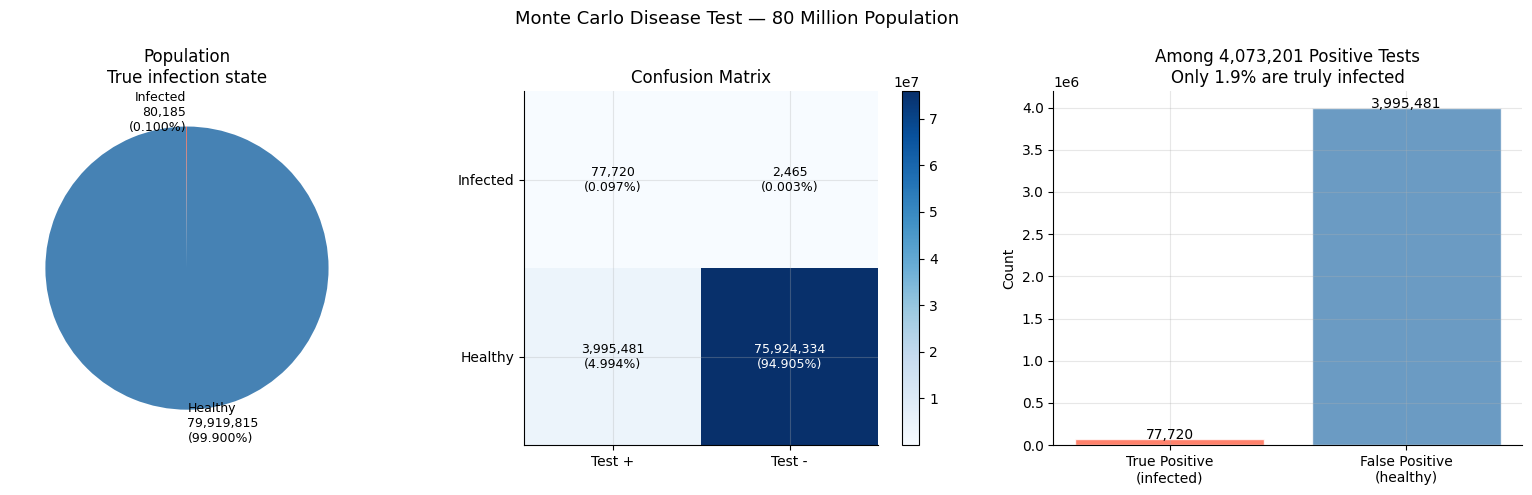

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel 1: Population breakdown ---
sizes  = [n_infected, n_healthy]
labels = [f'Infected\n{n_infected:,}\n({n_infected/N:.3%})',
          f'Healthy\n{n_healthy:,}\n({n_healthy/N:.3%})']
colors = ['tomato', 'steelblue']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='',
            startangle=90, textprops={'fontsize': 9})
axes[0].set_title('Population\nTrue infection state')

# --- Panel 2: Confusion matrix heatmap ---
cm = np.array([[TP, FN], [FP, TN]])
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Test +', 'Test -'])
axes[1].set_yticklabels(['Infected', 'Healthy'])
axes[1].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm[i,j]:,}\n({cm[i,j]/N:.3%})',
                     ha='center', va='center', fontsize=9,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[1])

# --- Panel 3: Among positive tests — true vs false ---
bars = axes[2].bar(['True Positive\n(infected)', 'False Positive\n(healthy)'],
                   [TP, FP],
                   color=['tomato', 'steelblue'], alpha=0.8, edgecolor='white')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Among {TP+FP:,} Positive Tests\nOnly {posterior_empirical:.1%} are truly infected')
for bar, val in zip(bars, [TP, FP]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=10)

plt.suptitle('Monte Carlo Disease Test — 80 Million Population', fontsize=13)
plt.tight_layout()
plt.savefig('monte_carlo_disease_test.png', dpi=150)
plt.show()

---
## Analytical vs Empirical — Side by Side

In [8]:
# Compare simulation results against Bayes' Theorem predictions across key metrics

metrics = {
    'P(infected | test +)':  (posterior_empirical,    posterior_analytical),
    'P(test + | infected)':  (TP/(TP+FN),             p_pos_given_infected),
    'P(test + | healthy)':   (FP/(FP+TN),             p_pos_given_healthy),
    'P(test +) overall':     ((TP+FP)/N,              p_positive),
}

print(f"{'Metric':<30} {'Simulation':>12} {'Analytical':>12} {'Difference':>12}")
print("-" * 70)
for metric, (empirical, analytical) in metrics.items():
    diff = abs(empirical - analytical)
    print(f"{metric:<30} {empirical:>12.6f} {analytical:>12.6f} {diff:>12.6f}")

print(f"\nAll differences are within expected sampling noise for N={N:,}.")
print(f"The simulation confirms Bayes' Theorem to high precision.")

Metric                           Simulation   Analytical   Difference
----------------------------------------------------------------------
P(infected | test +)               0.019081     0.019049     0.000031
P(test + | infected)               0.969259     0.970000     0.000741
P(test + | healthy)                0.049994     0.050000     0.000006
P(test +) overall                  0.050915     0.050920     0.000005

All differences are within expected sampling noise for N=80,000,000.
The simulation confirms Bayes' Theorem to high precision.


---
## Sampling Noise — How Stable Are the Results?

Run the simulation multiple times with different random seeds.
The posterior should converge toward the analytical value as N grows.

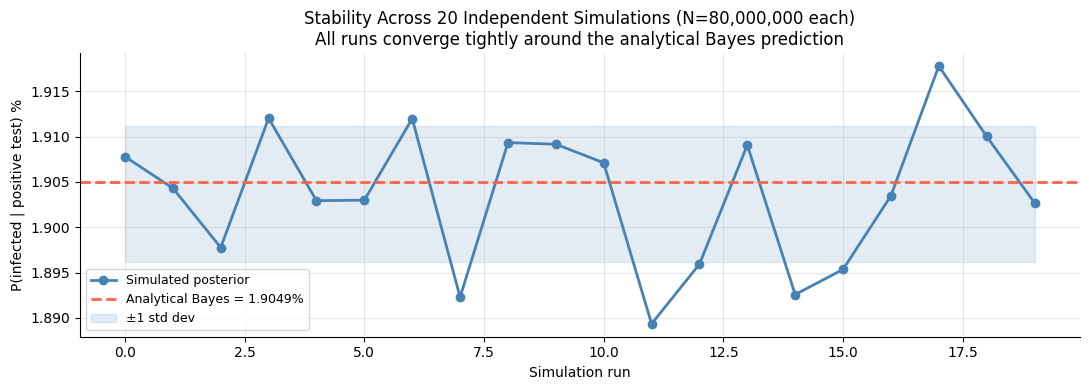

Analytical posterior : 0.019049
Simulation mean      : 0.019037
Simulation std dev   : 0.000075
Max deviation        : 0.000156


In [9]:
# Run 20 independent simulations and collect the posterior estimate each time
# This shows how much the result varies due to random sampling

n_runs     = 20
posteriors = []

for seed in range(n_runs):
    np.random.seed(seed)
    inf  = np.random.uniform(0, 1, N) < prior
    test = np.where(inf,
                    np.random.uniform(0, 1, N) < p_pos_given_infected,
                    np.random.uniform(0, 1, N) < p_pos_given_healthy)
    tp = ( inf &  test).sum()
    fp = (~inf &  test).sum()
    posteriors.append(tp / (tp + fp))

posteriors = np.array(posteriors)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(n_runs), posteriors * 100, 'o-', color='steelblue', lw=2, label='Simulated posterior')
ax.axhline(posterior_analytical * 100, color='tomato', lw=2,
           linestyle='--', label=f'Analytical Bayes = {posterior_analytical:.4%}')
ax.fill_between(range(n_runs),
                (posteriors.mean() - posteriors.std()) * 100,
                (posteriors.mean() + posteriors.std()) * 100,
                alpha=0.15, color='steelblue', label='±1 std dev')
ax.set_xlabel('Simulation run')
ax.set_ylabel('P(infected | positive test) %')
ax.set_title(f'Stability Across {n_runs} Independent Simulations (N={N:,} each)\nAll runs converge tightly around the analytical Bayes prediction')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('simulation_stability.png', dpi=150)
plt.show()

print(f"Analytical posterior : {posterior_analytical:.6f}")
print(f"Simulation mean      : {posteriors.mean():.6f}")
print(f"Simulation std dev   : {posteriors.std():.6f}")
print(f"Max deviation        : {np.abs(posteriors - posterior_analytical).max():.6f}")

---
## Summary

Simulating 80 million people and running the disease test empirically confirms Bayes' Theorem to high precision:

- The analytical posterior P(infected | positive) ≈ 1.9% is reproduced by simulation to within sampling noise
- Among all positive tests, false positives outnumber true positives by roughly **26:1**
- The simulation is stable across independent runs — the Law of Large Numbers ensures convergence at this scale

**The connection between the two approaches:**

Bayes' Theorem gives you the exact answer from first principles. Monte Carlo simulation gives you the same answer by brute force — generate the population, run the experiment, count the outcomes. Both are essential tools: Bayes for understanding and deriving, Monte Carlo for verifying and extending to cases where analytical solutions are intractable.

This relationship — analytical theory validated by simulation — is a cornerstone of computational science and data-driven modelling.